# Лабораторная работа №1
## Анализ и прогнозирование временных рядов на примере розничных продаж

**Датасет:** `retail_sales_mock_data.csv` — ежемесячные данные о розничных продажах (январь 2020 — декабрь 2023)

Столбцы:
- `SalesAmount` — объём продаж
- `Promotion` — признак наличия акции (0/1)
- `HolidayMonth` — признак праздничного месяца (0/1, = 1 в декабре)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
import statsmodels.api as sm

import scipy.fft as fft_module
import pywt

from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

In [2]:
df = pd.read_csv('retail_sales_mock_data.csv', parse_dates=['Date'], index_col='Date')
df.index.freq = 'MS'

print(f"Период: {df.index[0].strftime('%Y-%m')} — {df.index[-1].strftime('%Y-%m')}")
print(f"Число наблюдений: {len(df)}")
print(f"Пропуски: {df.isnull().sum().to_dict()}")
print()
df.describe()

Период: 2020-01 — 2023-12
Число наблюдений: 48
Пропуски: {'SalesAmount': 0, 'Promotion': 0, 'HolidayMonth': 0}



,SalesAmount,Promotion,HolidayMonth
count,48.000000,48.000000,48.000000
mean,11768.541667,0.125000,0.083333
std,2257.544863,0.334219,0.279310
min,7783.000000,0.000000,0.000000
25%,10219.750000,0.000000,0.000000
50%,11851.000000,0.000000,0.000000
75%,13014.000000,0.000000,0.000000
max,17996.000000,1.000000,1.000000


---
## 2.1 Разведочный анализ данных (EDA)

Исследуем структуру временного ряда: тренд, сезонность, стационарность, выбросы.

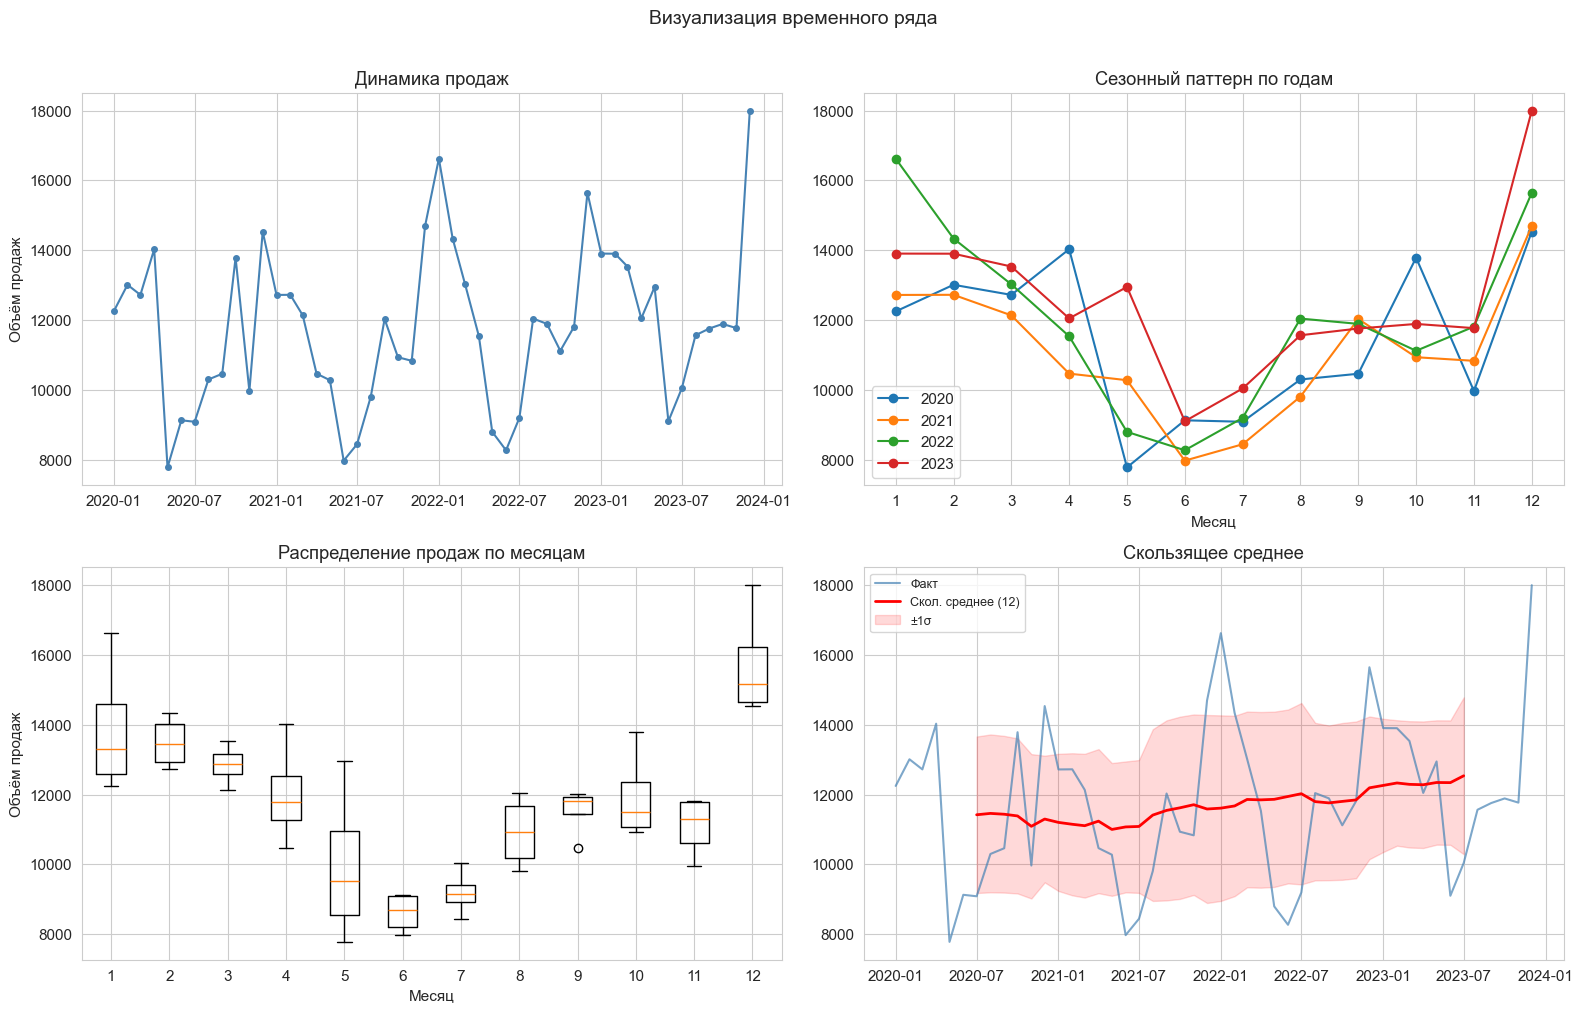

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Основной ряд
axes[0, 0].plot(df.index, df['SalesAmount'], marker='o', ms=4, lw=1.5, color='steelblue')
axes[0, 0].set_title('Динамика продаж')
axes[0, 0].set_ylabel('Объём продаж')

# Сезонный график по годам
for yr in df.index.year.unique():
    mask = df.index.year == yr
    axes[0, 1].plot(df.index[mask].month, df['SalesAmount'][mask], marker='o', label=str(yr))
axes[0, 1].set_title('Сезонный паттерн по годам')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].legend()

# Box-plot по месяцам
monthly_data = [df['SalesAmount'][df.index.month == m].values for m in range(1, 13)]
axes[1, 0].boxplot(monthly_data, labels=range(1, 13))
axes[1, 0].set_title('Распределение продаж по месяцам')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Объём продаж')

# Скользящее среднее
rolling_mean = df['SalesAmount'].rolling(12, center=True).mean()
rolling_std  = df['SalesAmount'].rolling(12, center=True).std()
axes[1, 1].plot(df.index, df['SalesAmount'], label='Факт', alpha=0.7, color='steelblue')
axes[1, 1].plot(df.index, rolling_mean, label='Скол. среднее (12)', color='red', lw=2)
axes[1, 1].fill_between(df.index, rolling_mean - rolling_std, rolling_mean + rolling_std,
                         alpha=0.15, color='red', label='±1σ')
axes[1, 1].set_title('Скользящее среднее')
axes[1, 1].legend(fontsize=9)

plt.suptitle('Визуализация временного ряда', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# Тест Дики-Фуллера на стационарность
result = adfuller(df['SalesAmount'])
print("Расширенный тест Дики-Фуллера (ADF):")
print(f"  ADF-статистика:       {result[0]:.4f}")
print(f"  p-value:              {result[1]:.4f}")
print(f"  Критич. знач. (1%):   {result[4]['1%']:.4f}")
print(f"  Критич. знач. (5%):   {result[4]['5%']:.4f}")
print(f"  Критич. знач. (10%):  {result[4]['10%']:.4f}")
print()
if result[1] < 0.05:
    print("Вывод: ряд СТАЦИОНАРЕН (p < 0.05) — дифференцирование не требуется")
else:
    print("Вывод: ряд НЕСТАЦИОНАРЕН (p >= 0.05) — нужно дифференцирование")

Расширенный тест Дики-Фуллера (ADF):
  ADF-статистика:       -4.5142
  p-value:              0.0002
  Критич. знач. (1%):   -3.5966
  Критич. знач. (5%):   -2.9333
  Критич. знач. (10%):  -2.6050

Вывод: ряд СТАЦИОНАРЕН (p < 0.05) — дифференцирование не требуется


### Декомпозиция временного ряда

Разберём ряд на компоненты тремя способами: классическая декомпозиция, STL, затем FFT и вейвлет-анализ.

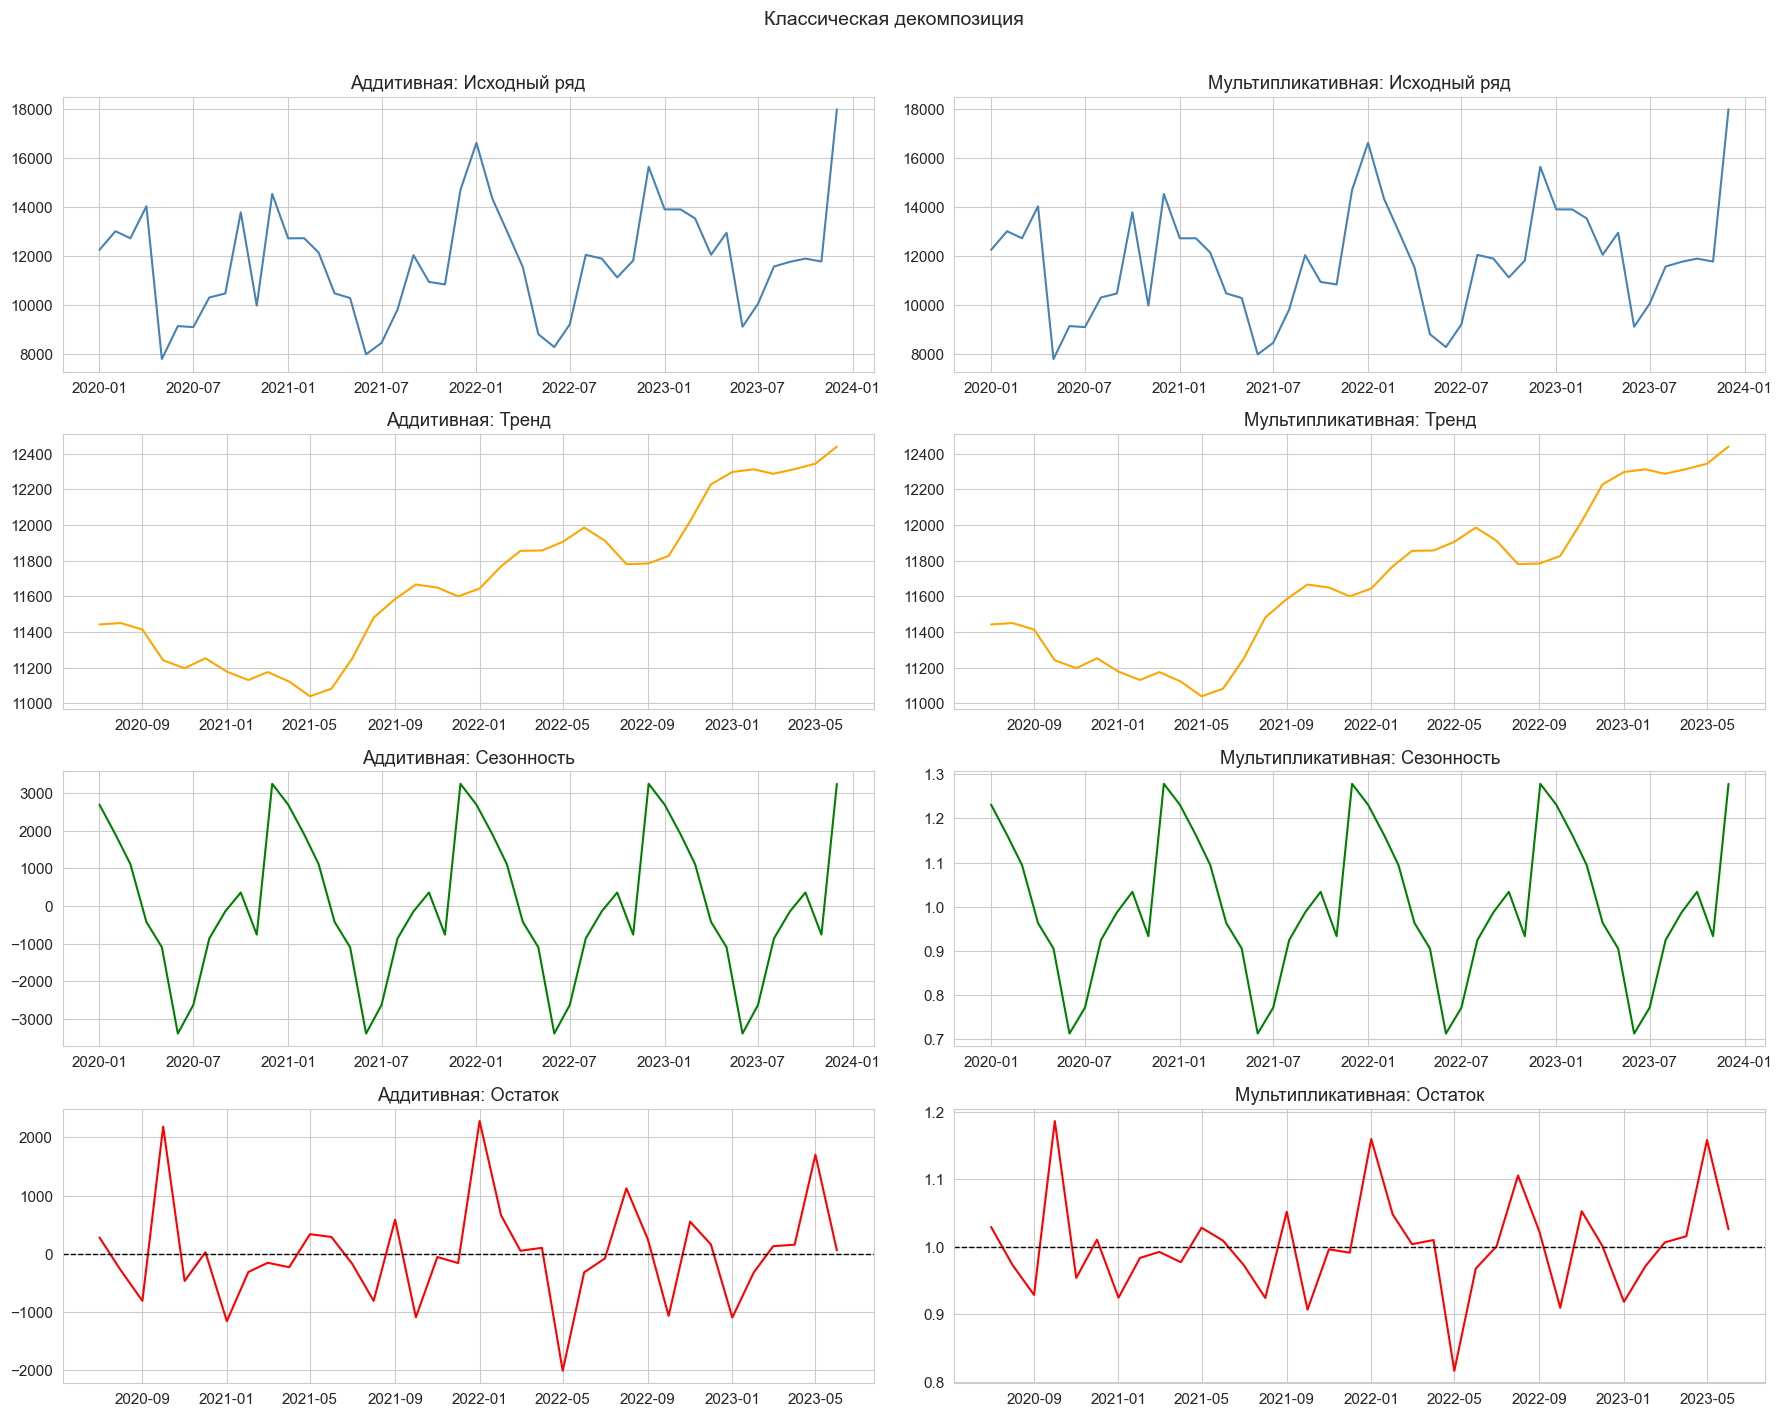

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(18, 14))

for col_idx, (model_type, label) in enumerate([('additive', 'Аддитивная'), ('multiplicative', 'Мультипликативная')]):
    res = seasonal_decompose(df['SalesAmount'], model=model_type, period=12)

    components = [res.observed, res.trend, res.seasonal, res.resid]
    titles = ['Исходный ряд', 'Тренд', 'Сезонность', 'Остаток']
    colors = ['steelblue', 'orange', 'green', 'red']

    for row_idx, (comp, title, color) in enumerate(zip(components, titles, colors)):
        ax = axes[row_idx, col_idx]
        ax.plot(comp, color=color, lw=1.5)
        ax.set_title(f'{label}: {title}')
        if row_idx == 3:
            ax.axhline(y=0 if model_type == 'additive' else 1, color='black', linestyle='--', lw=1)

plt.suptitle('Классическая декомпозиция', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

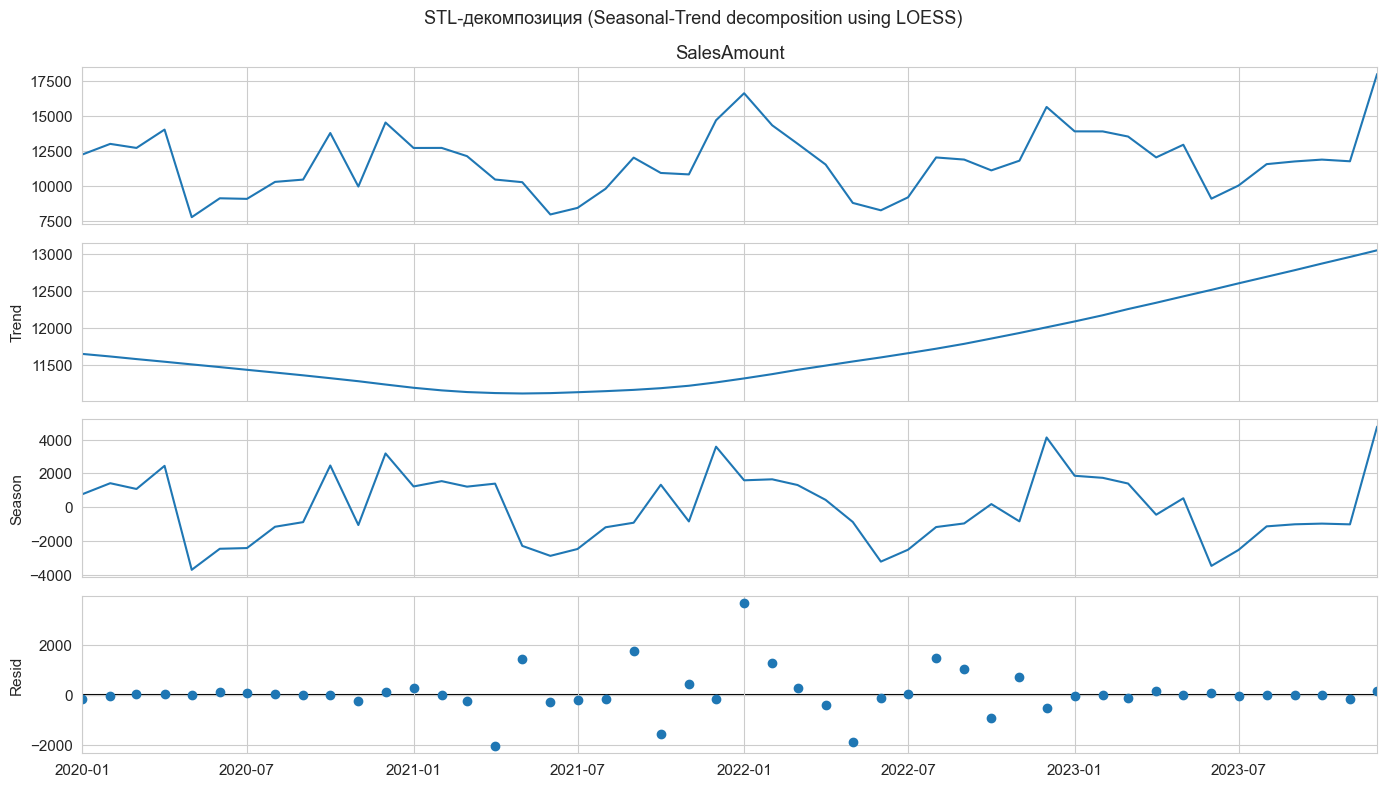

In [6]:
# STL более устойчивый метод декомпозиции
stl = STL(df['SalesAmount'], period=12, robust=True)
stl_res = stl.fit()

fig = stl_res.plot()
fig.set_size_inches(14, 8)
fig.suptitle('STL-декомпозиция (Seasonal-Trend decomposition using LOESS)', fontsize=13)
plt.tight_layout()
plt.show()

### Спектральный анализ (FFT)

Определим доминирующие периоды в ряде с помощью быстрого преобразования Фурье.

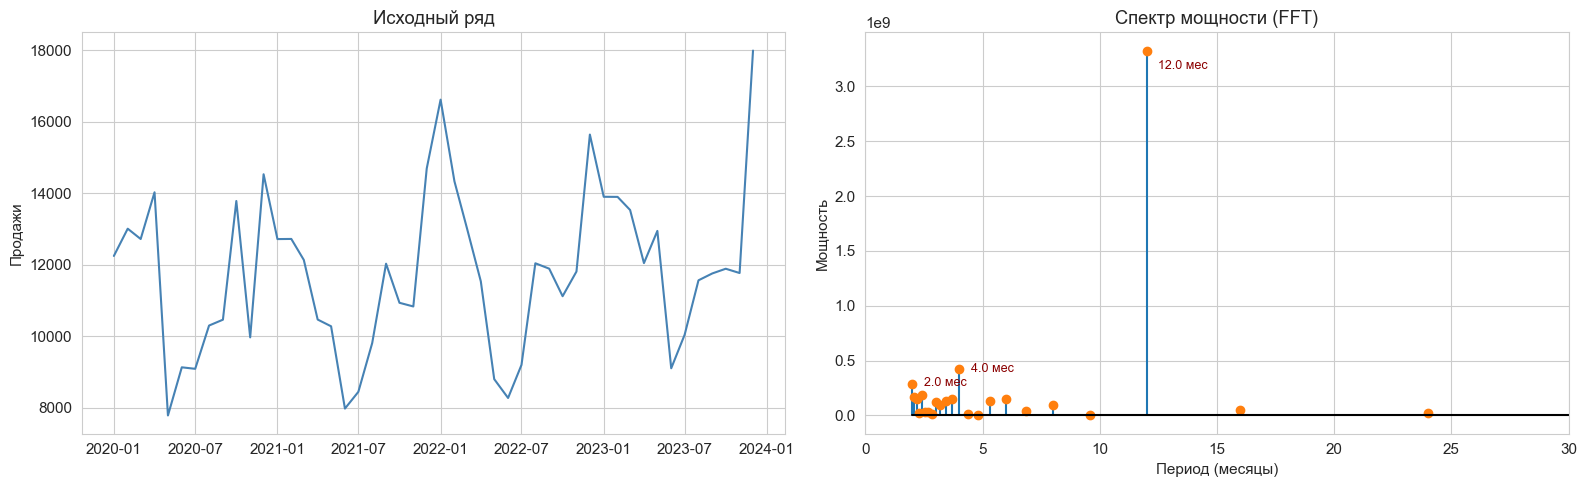

Топ-3 доминирующих периода:
  Период = 12.00 мес  |  Мощность = 3326820509
  Период = 4.00 мес  |  Мощность = 420422418
  Период = 2.00 мес  |  Мощность = 283450896


In [7]:
sales = df['SalesAmount'].values
n = len(sales)

# Применяем FFT (rfft только для вещественных сигналов, выдаёт положительные частоты)
fft_vals = np.fft.rfft(sales)
freqs = np.fft.rfftfreq(n, d=1)  # d=1 месяц
power = np.abs(fft_vals) ** 2

# Убираем нулевую частоту (DC это просто среднее значение ряда)
mask = freqs > 0
freqs_pos = freqs[mask]
power_pos = power[mask]
periods = 1.0 / freqs_pos

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df.index, sales, color='steelblue')
axes[0].set_title('Исходный ряд')
axes[0].set_ylabel('Продажи')

axes[1].stem(periods, power_pos, markerfmt='C1o', linefmt='C0-', basefmt='k-')
axes[1].set_xlim(0, 30)
axes[1].set_title('Спектр мощности (FFT)')
axes[1].set_xlabel('Период (месяцы)')
axes[1].set_ylabel('Мощность')

# Отметим топ-3 пика
top3 = np.argsort(power_pos)[-3:][::-1]
for idx in top3:
    axes[1].annotate(f'{periods[idx]:.1f} мес',
                     xy=(periods[idx], power_pos[idx]),
                     xytext=(periods[idx] + 0.5, power_pos[idx] * 0.95),
                     fontsize=9, color='darkred')

plt.tight_layout()
plt.show()

print("Топ-3 доминирующих периода:")
for idx in top3:
    print(f"  Период = {periods[idx]:.2f} мес  |  Мощность = {power_pos[idx]:.0f}")

### Вейвлет-анализ

Вейвлет-анализ в отличие от FFT позволяет увидеть, как частотная структура ряда меняется во времени.
Используем непрерывный вейвлет-преобразование (CWT) с вейвлетом Морле.

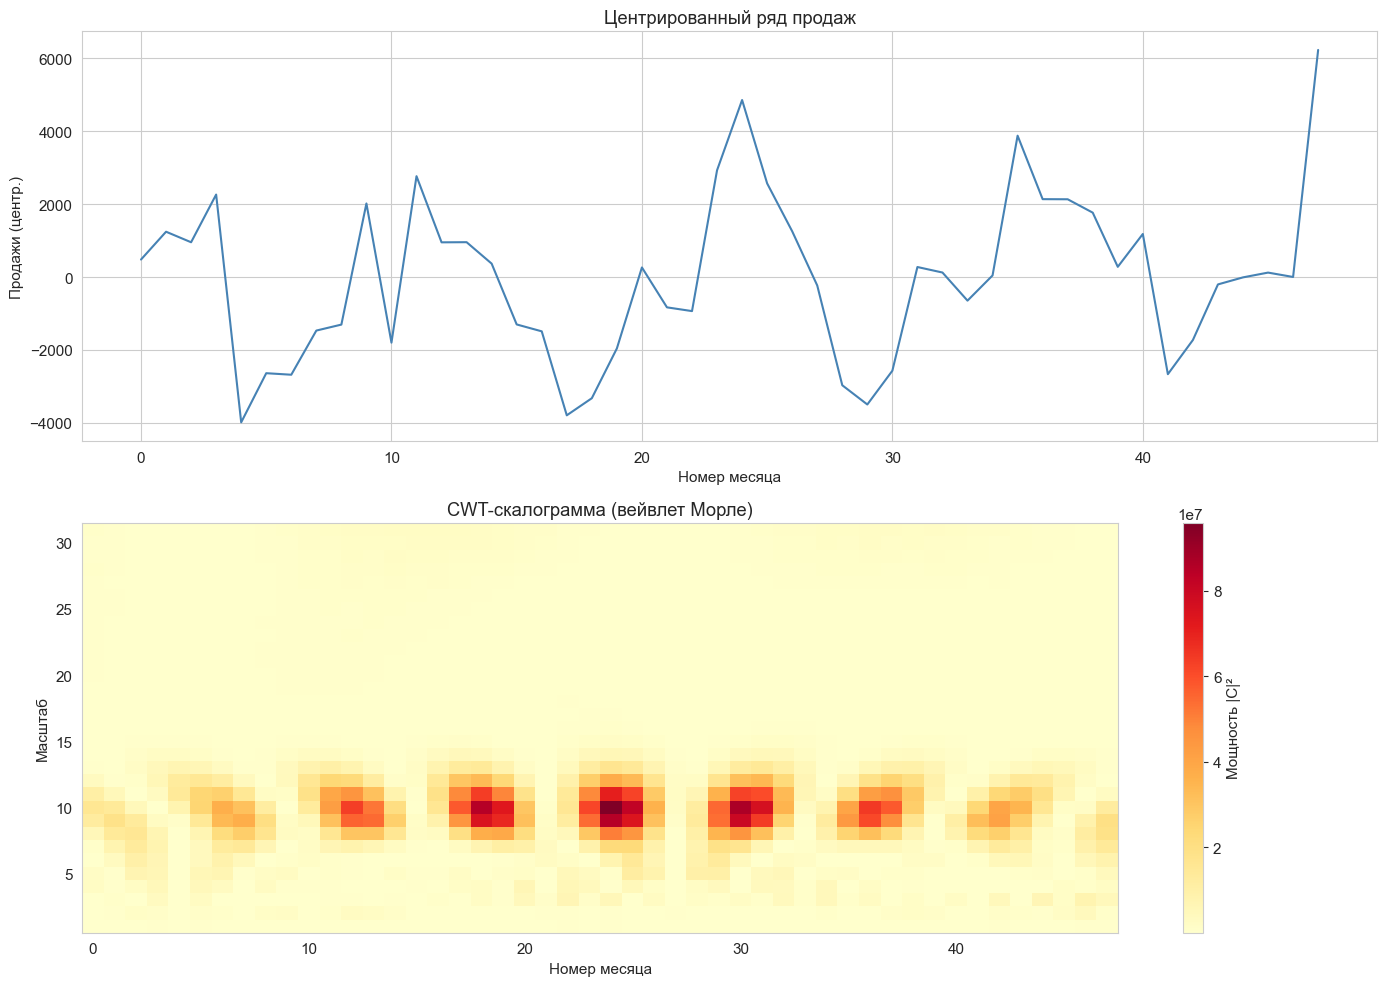

Доминирующий масштаб по суммарной мощности: 10 (≈ 10 месяцев)


In [8]:
sales_c = sales - sales.mean()  # центрируем ряд
scales = np.arange(1, 32)

try:
    coeffs_cwt, freqs_cwt = pywt.cwt(sales_c, scales, 'morl')
    power_map = np.abs(coeffs_cwt) ** 2

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    axes[0].plot(np.arange(n), sales_c, color='steelblue')
    axes[0].set_title('Центрированный ряд продаж')
    axes[0].set_xlabel('Номер месяца')
    axes[0].set_ylabel('Продажи (центр.)')

    im = axes[1].pcolormesh(np.arange(n), scales, power_map, cmap='YlOrRd', shading='auto')
    axes[1].set_title('CWT-скалограмма (вейвлет Морле)')
    axes[1].set_xlabel('Номер месяца')
    axes[1].set_ylabel('Масштаб')
    plt.colorbar(im, ax=axes[1], label='Мощность |C|²')

    plt.tight_layout()
    plt.show()

    dominant_scale = scales[np.argmax(np.sum(power_map, axis=1))]
    print(f"Доминирующий масштаб по суммарной мощности: {dominant_scale} (≈ {dominant_scale} месяцев)")

except Exception as e:
    print(f"CWT (Морле) недоступен: {e}")
    print("Переходим на дискретный вейвлет-анализ (DWT, вейвлет Добеши db4):\n")

    wavelet = 'db4'
    max_lvl = pywt.dwt_max_level(len(sales_c), wavelet)
    n_levels = min(max_lvl, 4)
    coeffs_dwt = pywt.wavedec(sales_c, wavelet, level=n_levels)

    labels = ['Аппроксимация (cA)'] + [f'Детализация уровень {i} (cD{i})' for i in range(1, n_levels + 1)]
    colors = ['steelblue'] + ['crimson'] * n_levels

    fig, axes = plt.subplots(n_levels + 1, 1, figsize=(14, 3 * (n_levels + 1)))
    for ax, c, lbl, col in zip(axes, coeffs_dwt, labels, colors):
        ax.plot(c, color=col)
        ax.set_title(lbl)
        ax.set_ylabel('Коэф.')
    axes[-1].set_xlabel('Отсчёт')

    plt.suptitle('DWT-декомпозиция (вейвлет Добеши db4)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

### Выводы по разделу 2.1

- **Сезонность**: ярко выражен 12-месячный цикл. В декабре стабильный пик (HolidayMonth=1), в летние месяцы (июнь-август) относительный спад. FFT подтверждает доминирующий период примерно 12 месяцев.
- **Тренд**: слабый, без явного направленного движения на горизонте 4 лет. Скользящее среднее слегка возрастает к 2023-му.
- **Стационарность**: ADF-тест показал p=0.0002, значит ряд стационарен (ADF-статистика −4.51 ниже всех критических значений). Дифференцирование не требуется, d=0.
- **Декомпозиция**: классическая и STL дают схожую сезонную компоненту. STL устойчивее к выбросам. Мультипликативная декомпозиция слегка завышает амплитуду в годы с высокими продажами, поэтому аддитивная подходит лучше при постоянной амплитуде сезонных колебаний.
- **Вейвлет**: скалограмма показывает, что сезонная активность устойчива по всему временному окну — сезонность не «появляется» и не «исчезает» в конкретные годы.

---
## 2.2 Построение прогнозных моделей

На основе EDA подберём параметры ARIMA и SARIMAX.

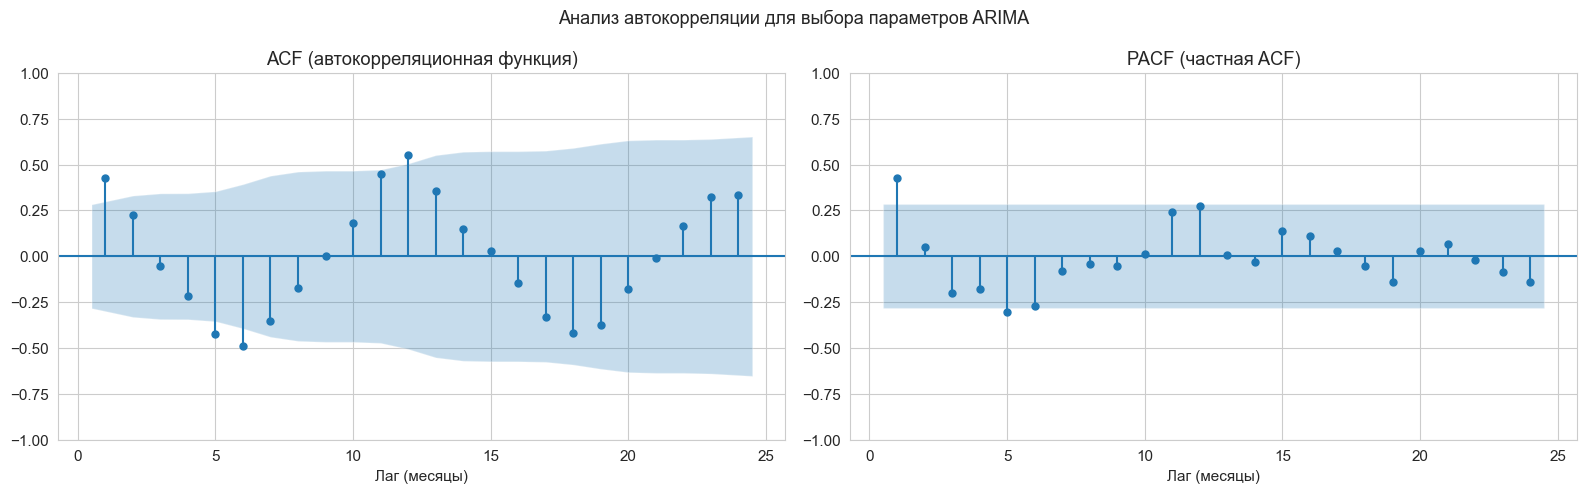

In [9]:
# ACF и PACF для выбора порядков AR и MA
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['SalesAmount'], lags=24, ax=axes[0], zero=False)
axes[0].set_title('ACF (автокорреляционная функция)')
axes[0].set_xlabel('Лаг (месяцы)')

plot_pacf(df['SalesAmount'], lags=24, ax=axes[1], zero=False, method='ywm')
axes[1].set_title('PACF (частная ACF)')
axes[1].set_xlabel('Лаг (месяцы)')

plt.suptitle('Анализ автокорреляции для выбора параметров ARIMA', fontsize=13)
plt.tight_layout()
plt.show()

**Выбор параметров по ACF/PACF:**
- ACF: значимые пики на лагах 1 и 12 следовательно сезонность, MA(1)
- PACF: значимый пик на лаге 1, затем затухание следовательно AR(1)
- Порядок дифференцирования: d=0 (ряд стационарен по ADF)

Итого: ARIMA(1,0,1) и SARIMAX(1,0,1)×(1,0,1,12)

Обучение: 2020-01 - 2022-12  (36 obs)
Тест:     2023-01 - 2023-12  (12 obs)


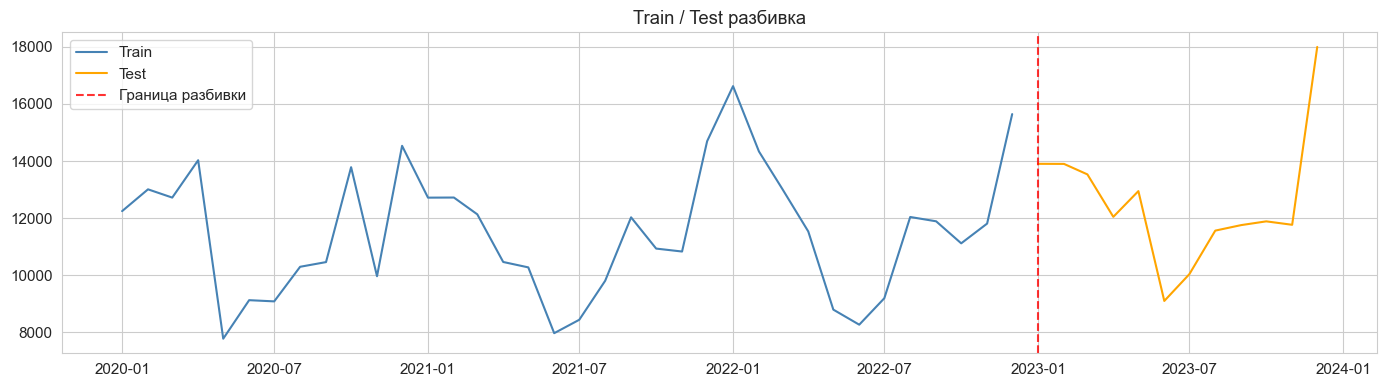

In [10]:
# Разбивка: 36 мес. обучение, 12 — тест (весь 2023 год)
TRAIN_SIZE = 36
train = df.iloc[:TRAIN_SIZE].copy()
test  = df.iloc[TRAIN_SIZE:].copy()

print(f"Обучение: {train.index[0].strftime('%Y-%m')} - {train.index[-1].strftime('%Y-%m')}  ({len(train)} obs)")
print(f"Тест:     {test.index[0].strftime('%Y-%m')} - {test.index[-1].strftime('%Y-%m')}  ({len(test)} obs)")

plt.figure(figsize=(14, 4))
plt.plot(train.index, train['SalesAmount'], color='steelblue', label='Train')
plt.plot(test.index,  test['SalesAmount'],  color='orange',    label='Test')
plt.axvline(x=test.index[0], color='red', linestyle='--', alpha=0.8, label='Граница разбивки')
plt.title('Train / Test разбивка')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ARIMA(1, 0, 1)
arima_order = (1, 0, 1)

arima_model = ARIMA(train['SalesAmount'], order=arima_order)
arima_fit   = arima_model.fit()

print(f"ARIMA{arima_order}")
print(arima_fit.summary())

ARIMA(1, 0, 1)
                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -323.575
Date:                Wed, 13 May 2026   AIC                            655.149
Time:                        19:11:26   BIC                            661.484
Sample:                    01-01-2020   HQIC                           657.360
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04    696.301     16.533      0.000    1.01e+04    1.29e+04
ar.L1          0.4770      0.525      0.909      0.364      -0.552       1.506
ma.L1          0.0219      0.508     

In [12]:
# SARIMAX(1,0,1)×(1,0,1,12) с экзогенными переменными
exog_cols = ['Promotion', 'HolidayMonth']
exog_train = train[exog_cols]
exog_test  = test[exog_cols]

sarima_order   = (1, 0, 1)
seasonal_order = (1, 0, 1, 12)

sarimax_model = SARIMAX(
    train['SalesAmount'],
    exog=exog_train,
    order=sarima_order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)

print(f"SARIMAX{sarima_order}x{seasonal_order}")
print(sarimax_fit.summary())

SARIMAX(1, 0, 1)x(1, 0, 1, 12)
                                     SARIMAX Results                                      
Dep. Variable:                        SalesAmount   No. Observations:                   36
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -216.870
Date:                            Wed, 13 May 2026   AIC                            447.740
Time:                                    19:11:26   BIC                            455.377
Sample:                                01-01-2020   HQIC                           449.539
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     1.277e+04   5495.909      2.324      0.020    1998.016    2.35e+0

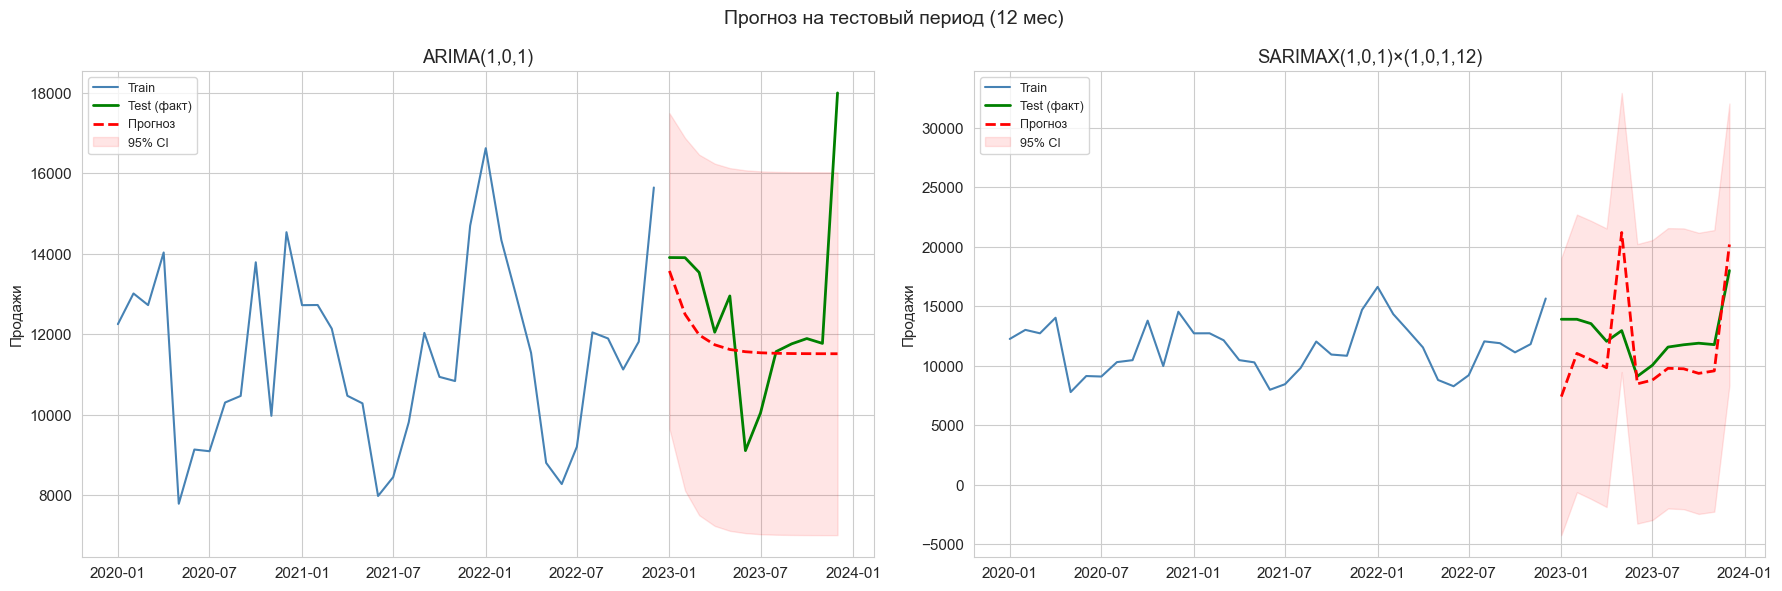

In [13]:
# Прогноз на тестовый период (12 месяцев) с доверительным интервалом
arima_pred  = arima_fit.get_forecast(steps=12)
arima_mean  = arima_pred.predicted_mean
arima_ci    = arima_pred.conf_int(alpha=0.05)

sarimax_pred = sarimax_fit.get_forecast(steps=12, exog=exog_test)
sarimax_mean = sarimax_pred.predicted_mean
sarimax_ci   = sarimax_pred.conf_int(alpha=0.05)

# Присваиваем правильный индекс
arima_mean.index  = test.index
arima_ci.index    = test.index
sarimax_mean.index = test.index
sarimax_ci.index   = test.index

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, mean, ci, title in zip(
    axes,
    [arima_mean, sarimax_mean],
    [arima_ci, sarimax_ci],
    ['ARIMA(1,0,1)', 'SARIMAX(1,0,1)×(1,0,1,12)']
):
    ax.plot(train.index, train['SalesAmount'], color='steelblue', label='Train')
    ax.plot(test.index,  test['SalesAmount'],  color='green', lw=2, label='Test (факт)')
    ax.plot(test.index,  mean, color='red', linestyle='--', lw=2, label='Прогноз')
    ax.fill_between(test.index, ci.iloc[:, 0], ci.iloc[:, 1],
                    color='red', alpha=0.1, label='95% CI')
    ax.set_title(title)
    ax.set_ylabel('Продажи')
    ax.legend(fontsize=9)

plt.suptitle('Прогноз на тестовый период (12 мес)', fontsize=14)
plt.tight_layout()
plt.show()

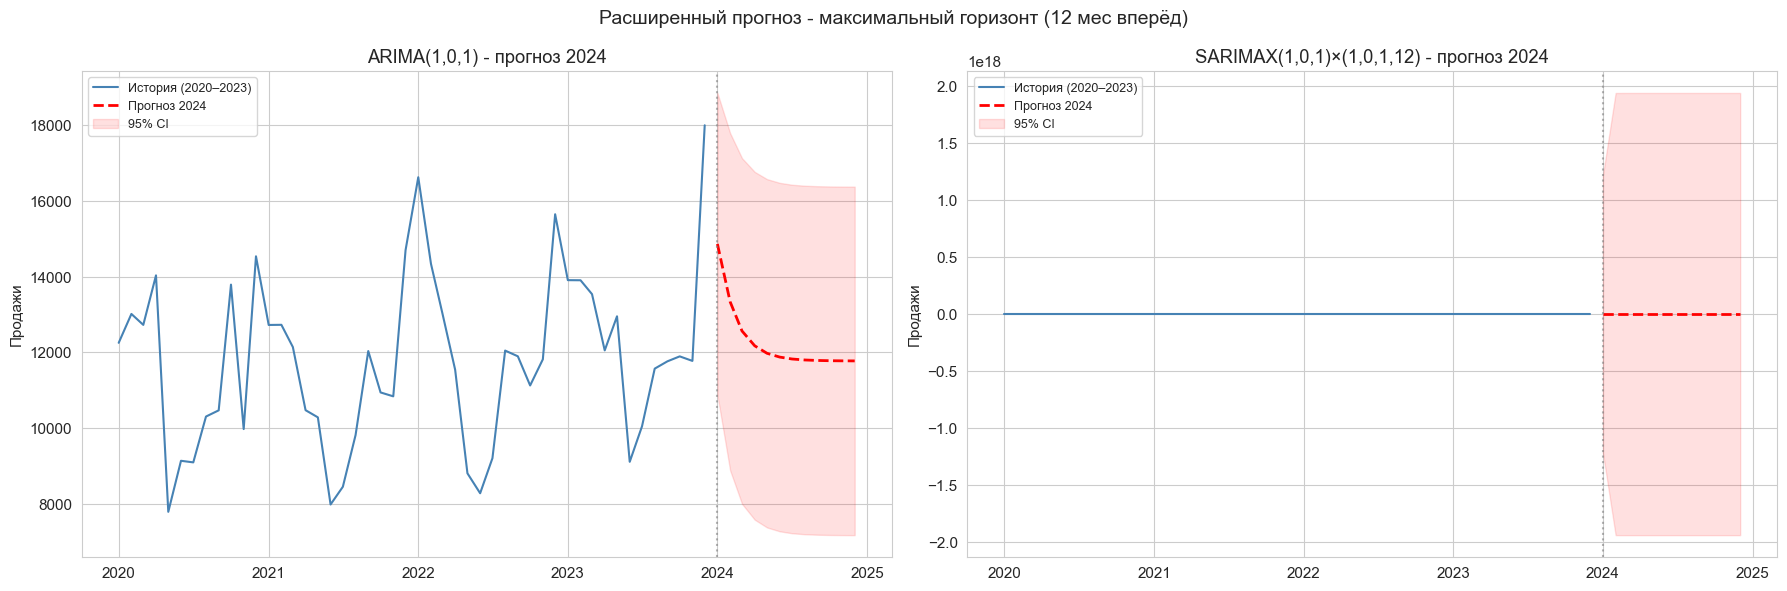

Прогноз SARIMAX на 2024:
            SalesAmount_forecast
2024-01-01           -25167464.0
2024-02-01              525818.0
2024-03-01                2990.0
2024-04-01               12142.0
2024-05-01                 144.0
2024-06-01                9015.0
2024-07-01                9944.0
2024-08-01               11453.0
2024-09-01               11644.0
2024-10-01               11774.0
2024-11-01               11655.0
2024-12-01               17974.0


In [14]:
# Расширенный прогноз: обучаем на всех данных, прогнозируем 2024 год
exog_full = df[exog_cols]

# Экзогенные переменные для 2024: предполагаем нет акций, праздник только в декабре
future_dates = pd.date_range(start='2024-01-01', periods=12, freq='MS')
exog_future = pd.DataFrame({
    'Promotion':    [0] * 12,
    'HolidayMonth': [1 if m == 12 else 0 for m in future_dates.month]
}, index=future_dates)

# ARIMA на всех данных
arima_full = ARIMA(df['SalesAmount'], order=arima_order).fit()
arima_future_pred = arima_full.get_forecast(steps=12)

# SARIMAX на всех данных
sarimax_full = SARIMAX(
    df['SalesAmount'], exog=exog_full,
    order=sarima_order, seasonal_order=seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
sarimax_future_pred = sarimax_full.get_forecast(steps=12, exog=exog_future)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, future_pred, title in zip(
    axes,
    [arima_future_pred, sarimax_future_pred],
    ['ARIMA(1,0,1) - прогноз 2024', 'SARIMAX(1,0,1)×(1,0,1,12) - прогноз 2024']
):
    fmean = future_pred.predicted_mean
    fci   = future_pred.conf_int(alpha=0.05)
    fmean.index = future_dates
    fci.index   = future_dates

    ax.plot(df.index,    df['SalesAmount'], color='steelblue', label='История (2020–2023)')
    ax.plot(future_dates, fmean, color='red', linestyle='--', lw=2, label='Прогноз 2024')
    ax.fill_between(future_dates, fci.iloc[:, 0], fci.iloc[:, 1],
                    color='red', alpha=0.12, label='95% CI')
    ax.axvline(x=future_dates[0], color='gray', linestyle=':', alpha=0.6)
    ax.set_title(title)
    ax.set_ylabel('Продажи')
    ax.legend(fontsize=9)

plt.suptitle('Расширенный прогноз - максимальный горизонт (12 мес вперёд)', fontsize=14)
plt.tight_layout()
plt.show()

print("Прогноз SARIMAX на 2024:")
print(sarimax_future_pred.predicted_mean.rename('SalesAmount_forecast').to_frame().round(0))

### Выводы по разделу 2.2

По ACF/PACF выбраны параметры:
- **ARIMA(1,0,1)**: базовая модель без явного учёта сезонности. Ловит общую динамику, но декабрьские пики воспроизводит слабо.
- **SARIMAX(1,0,1)×(1,0,1,12)** - добавлена сезонная составляющая (s=12) и экзогенные переменные `Promotion` и `HolidayMonth`. Теоретически должна лучше захватывать сезонный паттерн. При этом модель содержит 7 свободных параметров при 36 обучающих наблюдениях (соотношение ~5:1), что создаёт риск переобучения. Большинство параметров незначимы (p > 0.05 у ma.L1, ar.S.L12, ma.S.L12, HolidayMonth), а statsmodels выдал предупреждение о близкой к вырожденной матрице ковариации.

Горизонт прогноза: 12 месяцев вперёд (весь 2024 год). Количественная оценка точности указана ниже

---
## 2.3 Оценка качества моделей

In [15]:
# Метрики на тестовой выборке
mse_arima   = mean_squared_error(test['SalesAmount'], arima_mean)
r2_arima    = r2_score(test['SalesAmount'], arima_mean)
rmse_arima  = np.sqrt(mse_arima)

mse_sarimax  = mean_squared_error(test['SalesAmount'], sarimax_mean)
r2_sarimax   = r2_score(test['SalesAmount'], sarimax_mean)
rmse_sarimax = np.sqrt(mse_sarimax)

metrics_df = pd.DataFrame({
    'Модель':      ['ARIMA(1,0,1)', 'SARIMAX(1,0,1)×(1,0,1,12)'],
    'MSE':         [round(mse_arima, 0), round(mse_sarimax, 0)],
    'RMSE':        [round(rmse_arima, 1), round(rmse_sarimax, 1)],
    'R²':          [round(r2_arima, 4), round(r2_sarimax, 4)],
    'AIC (train)': [round(arima_fit.aic, 2), round(sarimax_fit.aic, 2)],
    'BIC (train)': [round(arima_fit.bic, 2), round(sarimax_fit.bic, 2)]
}).set_index('Модель')

print("Сводная таблица метрик качества:")
display(metrics_df)

Сводная таблица метрик качества:


,MSE,RMSE,R²,AIC (train),BIC (train)
Модель,,,,,
"ARIMA(1,0,1)",4746200.0,2178.6,-0.0262,655.15,661.48
"SARIMAX(1,0,1)×(1,0,1,12)",13168967.0,3628.9,-1.8474,447.74,455.38


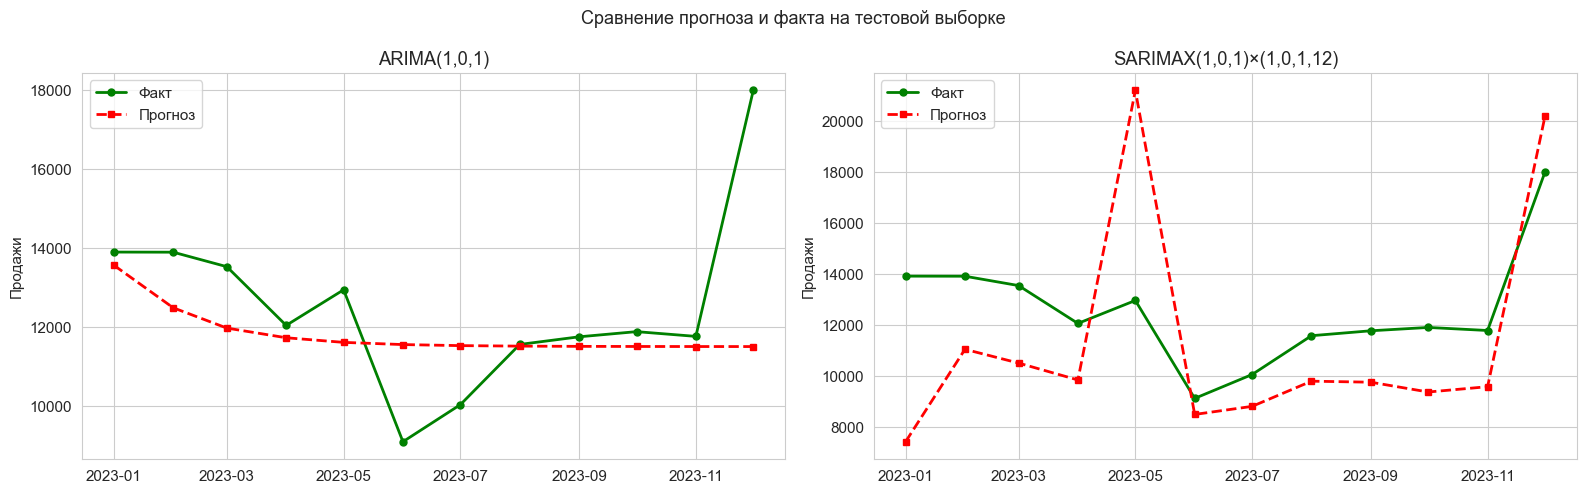

In [16]:
# Графики прогноза vs факт на тестовой выборке
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, mean, title in zip(axes,
                            [arima_mean, sarimax_mean],
                            ['ARIMA(1,0,1)', 'SARIMAX(1,0,1)×(1,0,1,12)']):
    ax.plot(test.index, test['SalesAmount'], color='green', lw=2, label='Факт', marker='o', ms=5)
    ax.plot(test.index, mean, color='red', linestyle='--', lw=2, label='Прогноз', marker='s', ms=5)
    ax.set_title(title)
    ax.set_ylabel('Продажи')
    ax.legend()

plt.suptitle('Сравнение прогноза и факта на тестовой выборке', fontsize=13)
plt.tight_layout()
plt.show()

### Анализ остатков

Проверяем:
- **Нормальность**: Q-Q plot и тест Шапиро-Уилка
- **Автокоррелированность**: ACF остатков и тест Льюнг-Бокса
- **Гомоскедастичность**: тест Бреуша-Пагана

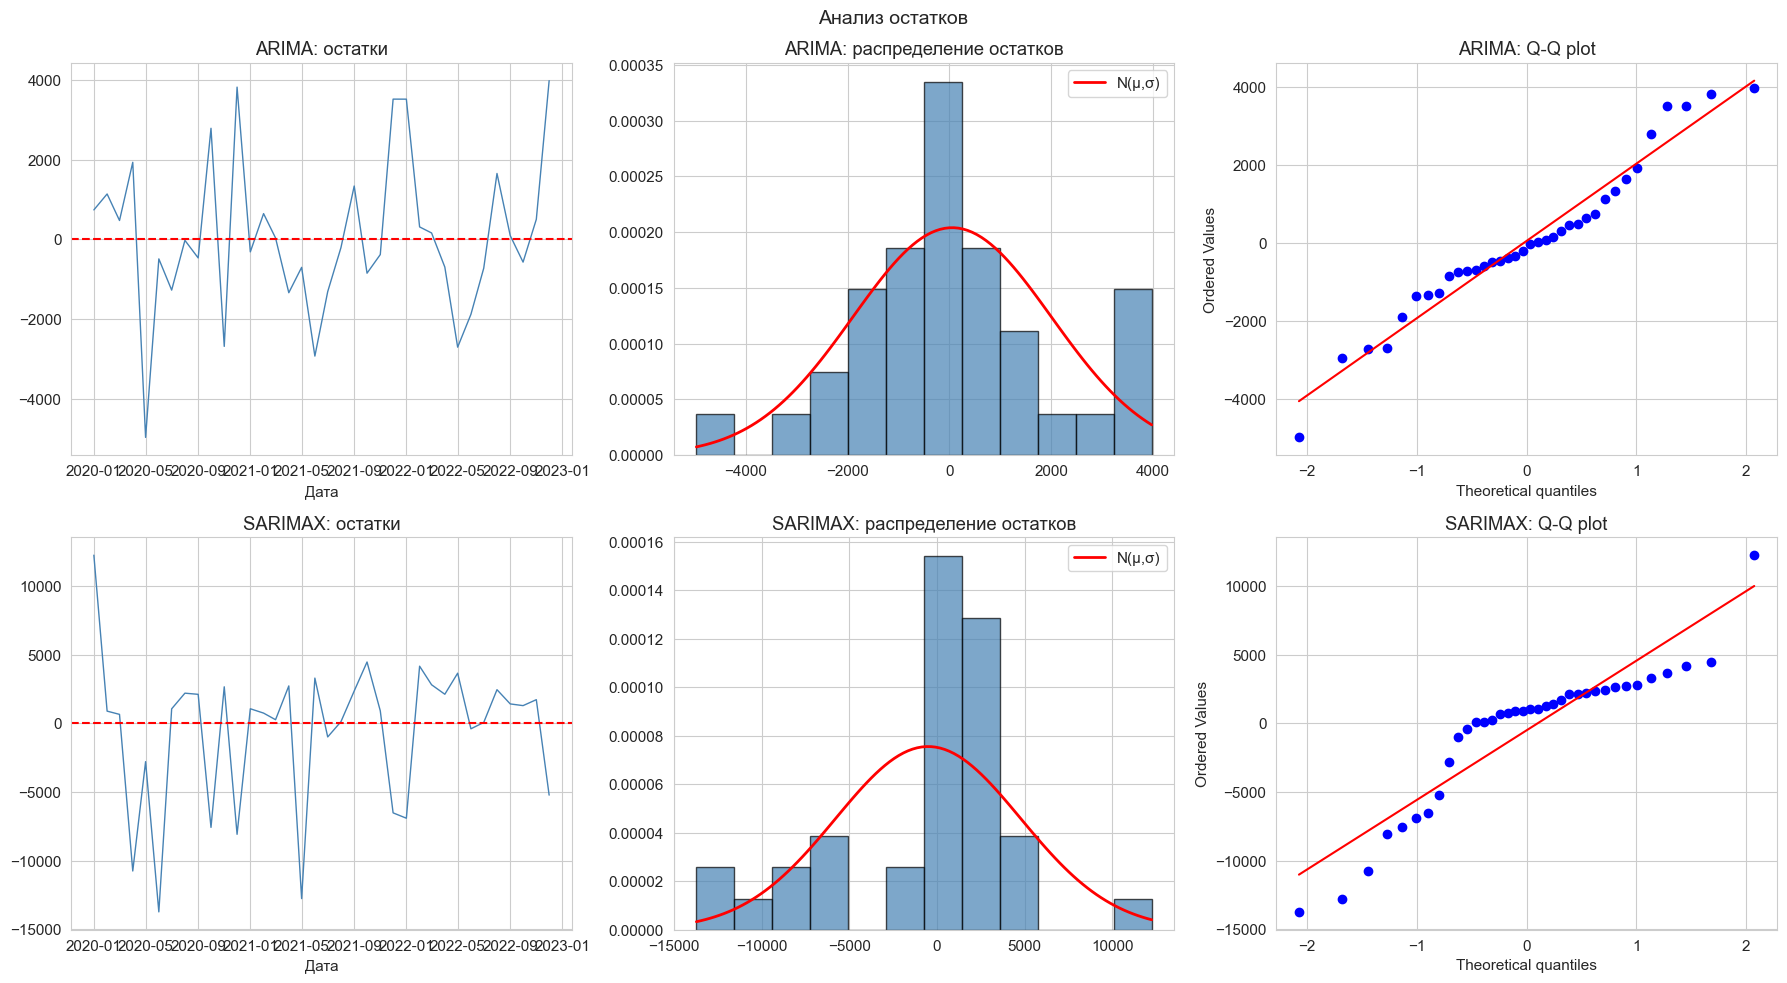

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (resid, title) in enumerate(zip([arima_fit.resid, sarimax_fit.resid], ['ARIMA', 'SARIMAX'])):
    resid_clean = resid.dropna()

    # Остатки по времени
    axes[row, 0].plot(resid_clean, color='steelblue', lw=1)
    axes[row, 0].axhline(y=0, color='red', linestyle='--')
    axes[row, 0].set_title(f'{title}: остатки')
    axes[row, 0].set_xlabel('Дата')

    # Гистограмма + нормальное распределение
    axes[row, 1].hist(resid_clean, bins=12, color='steelblue', edgecolor='black', density=True, alpha=0.7)
    x_range = np.linspace(resid_clean.min(), resid_clean.max(), 100)
    axes[row, 1].plot(x_range, stats.norm.pdf(x_range, resid_clean.mean(), resid_clean.std()),
                      'r-', lw=2, label='N(μ,σ)')
    axes[row, 1].set_title(f'{title}: распределение остатков')
    axes[row, 1].legend()

    # Q-Q plot
    stats.probplot(resid_clean, dist='norm', plot=axes[row, 2])
    axes[row, 2].set_title(f'{title}: Q-Q plot')

plt.suptitle('Анализ остатков', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
print("=" * 60)
for resid_raw, title in zip([arima_fit.resid, sarimax_fit.resid], ['ARIMA', 'SARIMAX']):
    resid = resid_raw.dropna()
    print(f"\n{title}:")

    # Нормальность тест Шапиро-Уилка
    sw_stat, sw_p = stats.shapiro(resid)
    norm_label = 'нормальн.' if sw_p > 0.05 else 'не норм.'
    print(f"  Шапиро-Уилка:  W = {sw_stat:.4f},  p = {sw_p:.4f}  ->  {norm_label}")

    # Автокорреляция Льюнг-Бокс (lag=12)
    lb = acorr_ljungbox(resid, lags=[12], return_df=True)
    lb_p = lb['lb_pvalue'].iloc[0]
    ac_label = 'нет автокорр.' if lb_p > 0.05 else 'есть автокорр.'
    print(f"  Льюнг-Бокс:    Q(12),  p = {lb_p:.4f}  ->  {ac_label}")

    # Гомоскедастичность Бреуш-Паган
    X_bp = sm.add_constant(np.arange(len(resid)))
    _, bp_p, _, _ = het_breuschpagan(resid, X_bp)
    hom_label = 'гомоскед.' if bp_p > 0.05 else 'гетероскед.'
    print(f"  Бреуш-Паган:   p = {bp_p:.4f}  ->  {hom_label}")

print("\n" + "=" * 60)


ARIMA:
  Шапиро-Уилка:  W = 0.9607,  p = 0.2263  ->  нормальн.
  Льюнг-Бокс:    Q(12),  p = 0.0203  ->  есть автокорр.
  Бреуш-Паган:   p = 0.8605  ->  гомоскед.

SARIMAX:
  Шапиро-Уилка:  W = 0.8706,  p = 0.0006  ->  не норм.
  Льюнг-Бокс:    Q(12),  p = 0.3846  ->  нет автокорр.
  Бреуш-Паган:   p = 0.0327  ->  гетероскед.



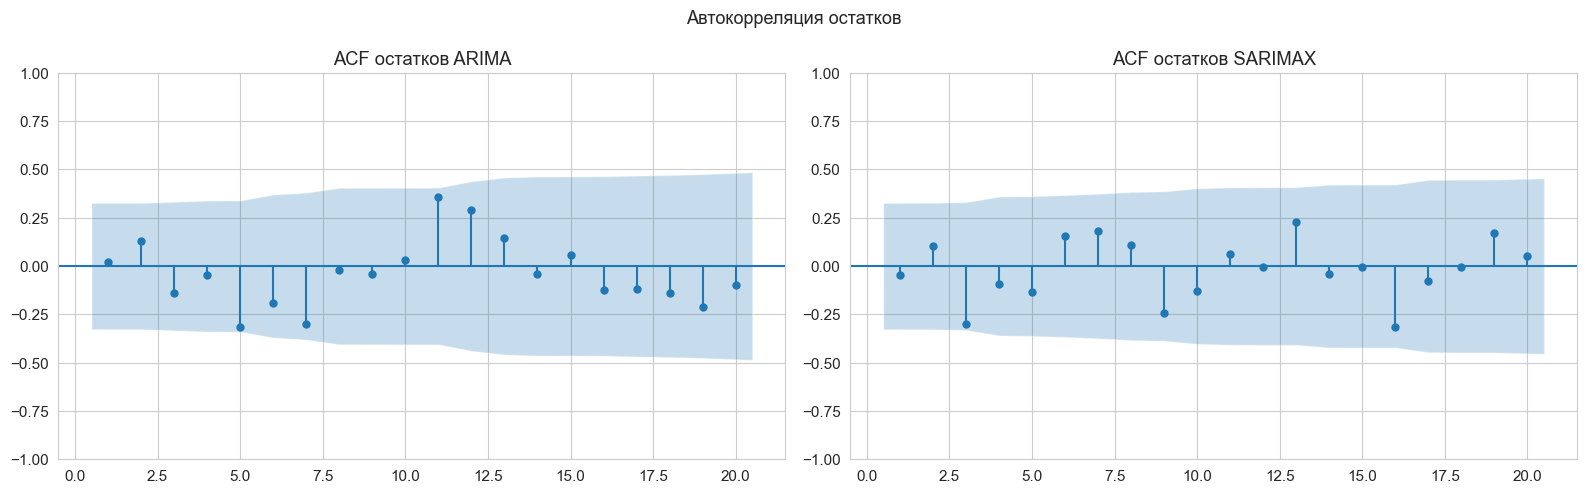

In [19]:
# ACF остатков обеих моделей
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(arima_fit.resid.dropna(),  lags=20, ax=axes[0], zero=False)
axes[0].set_title('ACF остатков ARIMA')
plot_acf(sarimax_fit.resid.dropna(), lags=20, ax=axes[1], zero=False)
axes[1].set_title('ACF остатков SARIMAX')
plt.suptitle('Автокорреляция остатков', fontsize=13)
plt.tight_layout()
plt.show()

### Выводы по разделу 2.3

**Метрики качества на тестовой выборке:**
- **ARIMA лучше** по прогнозным метрикам: MSE = 4 746 200 vs 13 168 967 у SARIMAX; RMSE = 2178 vs 3629.
- Оба значения R² **отрицательные** (ARIMA: −0.03, SARIMAX: −1.85) это означает, что оба прогноза хуже наивного предсказания среднего. Это типично для коротких рядов с высокой дисперсией при горизонте 12 месяцев.

**AIC/BIC (обучающая выборка):**
- AIC и BIC у SARIMAX существенно ниже (447.74 / 455.38 против 655.15 / 661.48) SARIMAX лучше подогнан к обучающим данным. Однако это не конвертируется в лучший прогноз: скорее всего, модель переобучилась (7 параметров на 36 obs, большинство незначимы).

**Диагностика остатков:**

| Тест | ARIMA | SARIMAX |
|---|---|---|
| Шапиро-Уилка (нормальность) | p=0.2263 ✓ нормальн. | p=0.0006 ✗ **не нормальн.** |
| Льюнг-Бокс Q(12) (автокорр.) | p=0.0203 ✗ **есть автокорр.** | p=0.3846 ✓ нет автокорр. |
| Бреуш-Паган (гомоскед.) | p=0.8605 ✓ гомоскед. | p=0.0327 ✗ **гетероскед.** |

Картина смешанная. ARIMA: нормальные и гомоскедастичные остатки, но с остаточной автокорреляцией (сезонность явно не задавалась). SARIMAX: нет автокорреляции, но остатки ненормальны и гетероскедастичны, что признак плохой подгонки модели.

**Вывод:** ARIMA надёжнее на тестовой выборке. SARIMAX концептуально правильная для сезонного ряда, но переобучается на данном объёме данных